# Regression Trees & Random Forest Regression

## Libraries and settings

In [31]:
# Libraries
import os
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/data_analytics/Week_08


## Import the apartment data

In [32]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";", encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

# Reset index
df = df.reset_index(drop=True)

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


## Regression Tree
See also: https://data36.com/regression-tree-python-scikit-learn

### Create train and test samples for the regression tree (train = 80%, test = 20% of the data)

In [33]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df[['area', 
                                                        'rooms',
                                                        'pop_dens',
                                                        'mean_taxable_income',
                                                        'dist_supermarket']], 
                                                        df['price'], 
                                                        test_size=0.20, 
                                                        random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
     area  rooms     pop_dens  mean_taxable_income  dist_supermarket
456   120    6.5   165.018625          65380.98802       1958.318650
6      65    3.5   525.662252         111422.35870        282.095910
362    90    3.5   424.146342          72133.75058       2606.231069
594    63    2.5  1044.628957          70964.08794        564.607066
439    91    3.5   399.525129          62000.54187        646.823905 

y_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the regression tree model

In [34]:
# Create decision tree regressor object
reg = DecisionTreeRegressor(random_state=20, max_depth=3)

# Train decision tree regressor
reg = reg.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = reg.predict(X_test)

In [35]:
reg2 = DecisionTreeRegressor(random_state=20, max_depth=5)
reg2 = reg2.fit(X_train, y_train)
y2_pred = reg2.predict(X_test)

### Calculate coefficient of determination (R-squared)

In [36]:
# Calculate coefficient of determination, round to 4 decimals
r2 = float(r2_score(y_test, y_pred))
print(f'R-squared (max_depth=3): {r2:.4f}')
r2_2 = float(r2_score(y_test, y2_pred))
print(f'R-squared (max_depth=5): {r2_2:.4f}')

R-squared (max_depth=3): 0.4502
R-squared (max_depth=5): 0.5247


In [37]:
# Text representation of the regression tree
text_representation = tree.export_text(reg, 
                                       feature_names=list(X_train.columns))

# Print text_representation
print(text_representation)

|--- area <= 99.50
|   |--- pop_dens <= 4269.10
|   |   |--- area <= 77.50
|   |   |   |--- value: [1722.86]
|   |   |--- area >  77.50
|   |   |   |--- value: [2191.39]
|   |--- pop_dens >  4269.10
|   |   |--- area <= 52.50
|   |   |   |--- value: [1893.80]
|   |   |--- area >  52.50
|   |   |   |--- value: [2927.78]
|--- area >  99.50
|   |--- area <= 134.00
|   |   |--- pop_dens <= 3874.83
|   |   |   |--- value: [2672.06]
|   |   |--- pop_dens >  3874.83
|   |   |   |--- value: [3603.59]
|   |--- area >  134.00
|   |   |--- pop_dens <= 1663.59
|   |   |   |--- value: [3391.42]
|   |   |--- pop_dens >  1663.59
|   |   |   |--- value: [4154.83]



In [38]:
text_representation2 = tree.export_text(reg2, 
                                       feature_names=list(X_train.columns))
print(text_representation2)

|--- area <= 99.50
|   |--- pop_dens <= 4269.10
|   |   |--- area <= 77.50
|   |   |   |--- rooms <= 1.25
|   |   |   |   |--- area <= 35.50
|   |   |   |   |   |--- value: [1153.83]
|   |   |   |   |--- area >  35.50
|   |   |   |   |   |--- value: [1325.00]
|   |   |   |--- rooms >  1.25
|   |   |   |   |--- area <= 69.50
|   |   |   |   |   |--- value: [1698.66]
|   |   |   |   |--- area >  69.50
|   |   |   |   |   |--- value: [1884.28]
|   |   |--- area >  77.50
|   |   |   |--- mean_taxable_income <= 96728.41
|   |   |   |   |--- pop_dens <= 1030.49
|   |   |   |   |   |--- value: [1995.61]
|   |   |   |   |--- pop_dens >  1030.49
|   |   |   |   |   |--- value: [2257.40]
|   |   |   |--- mean_taxable_income >  96728.41
|   |   |   |   |--- mean_taxable_income <= 166929.42
|   |   |   |   |   |--- value: [2604.00]
|   |   |   |   |--- mean_taxable_income >  166929.42
|   |   |   |   |   |--- value: [3055.00]
|   |--- pop_dens >  4269.10
|   |   |--- area <= 52.50
|   |   |   |---

### Vizualizing the regression tree

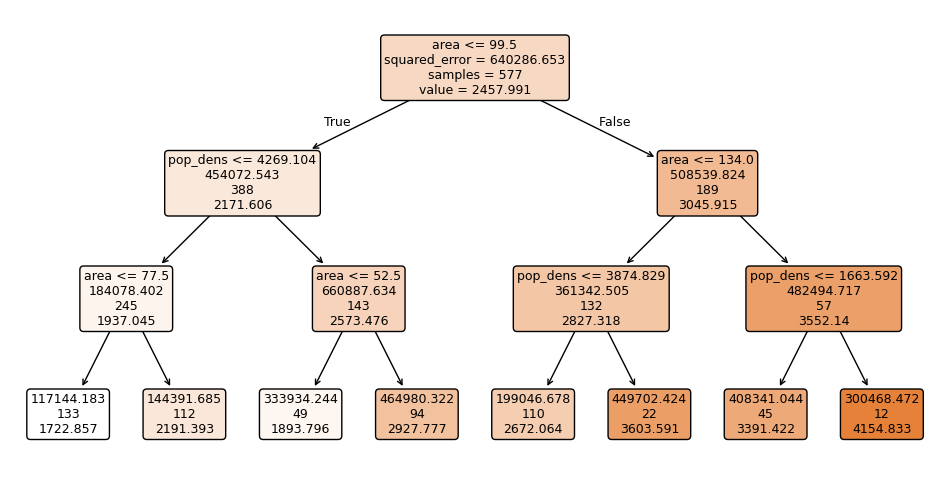

In [39]:
fig = plt.figure(figsize=(12,6))
_ = tree.plot_tree(reg, 
                   feature_names=list(X_train.columns),  
                   class_names=['price'],
                   filled=True,
                   fontsize=9,
                   label='root',
                   rounded=True)

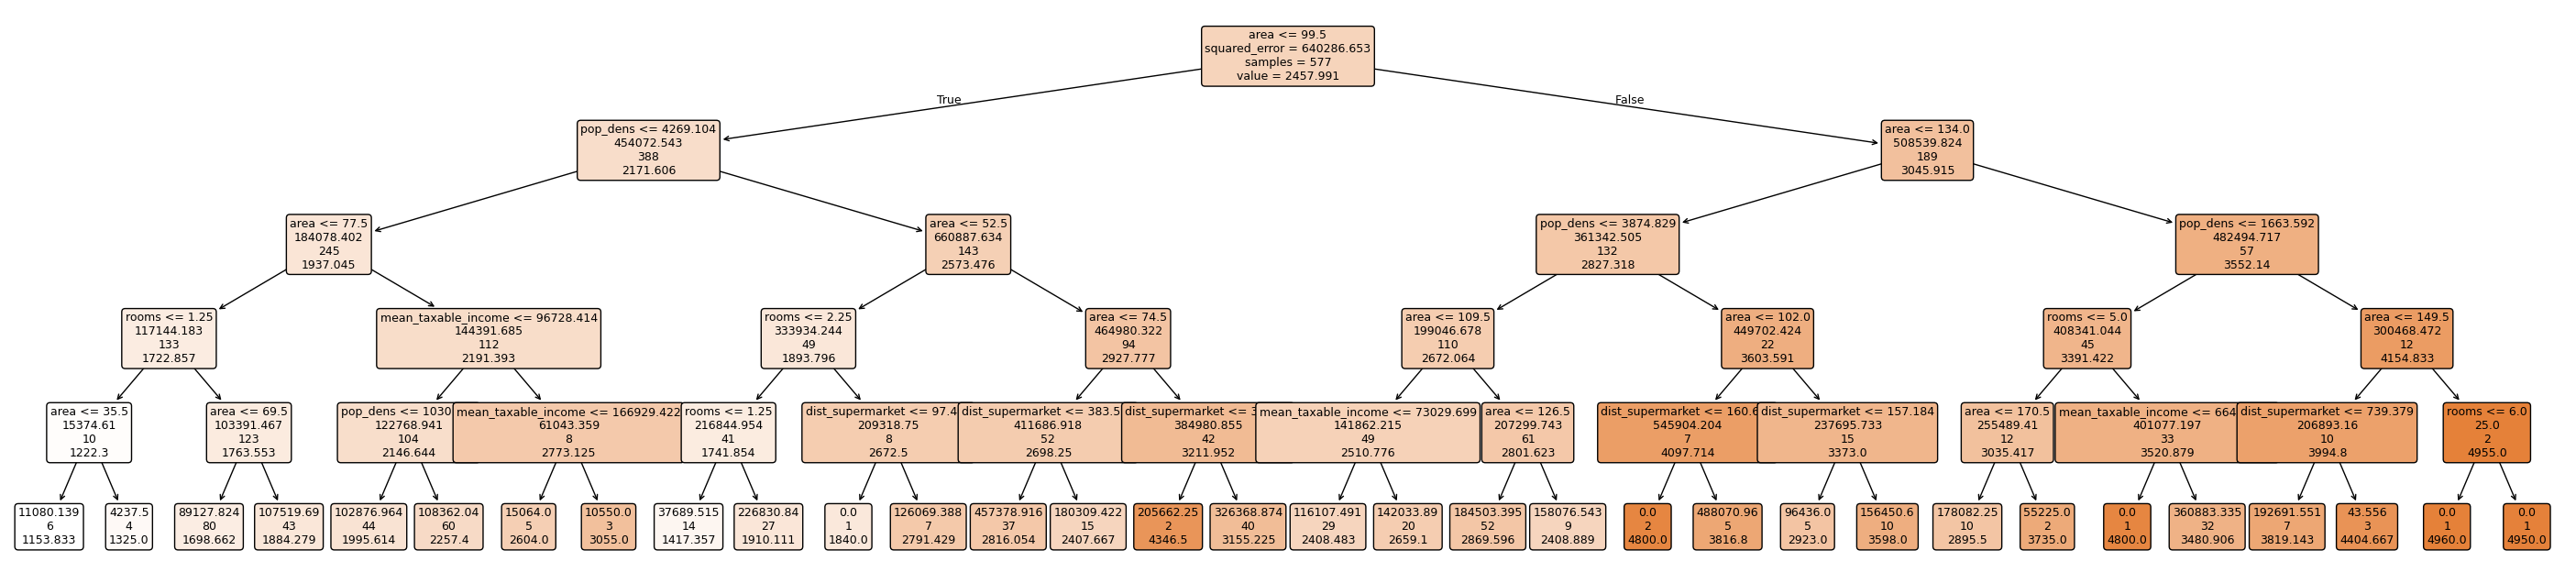

In [40]:
fig = plt.figure(figsize=(36,8))
_ = tree.plot_tree(reg2, 
                   feature_names=list(X_train.columns),  
                   class_names=['price'],
                   filled=True,
                   fontsize=9,
                   label='root',
                   rounded=True)

Increasing the maximum depth of the regression tree from 3 to 5 leads to a more complex model with a larger number of splits and terminal nodes, as clearly shown in the graphical representation. The deeper tree captures more detailed and localized patterns in the data, which is reflected in the higher R-squared value (from 0.4502 to 0.5247).

### Coeficient of determination (removing `area` and `rooms`)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(df[['pop_dens',
                                                        'mean_taxable_income',
                                                        'dist_supermarket']], 
                                                        df['price'], 
                                                        test_size=0.20, 
                                                        random_state=42)
reg3 = DecisionTreeRegressor(random_state=20, max_depth=3)
reg3 = reg3.fit(X_train, y_train)
y3_pred = reg3.predict(X_test)

r2_3 = float(r2_score(y_test, y3_pred))
print(f'R-squared (3 vars): {r2_3:.4f}')


R-squared (3 vars): 0.0504


After removing the variables area and rooms from the regression tree, the R-squared value drops substantially (to around 0.05, and even lower for a deeper tree). This result is mainly driven by the removal of area, which has the highest feature importance and accounts for most of the explanatory power of the model, while rooms contributes comparatively little. Without area, the remaining variables provide only weak predictive information, and increasing the tree depth mainly leads to overfitting on noise rather than improving model performance.

## Random Forest Regression
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### Create train and test samples for the random forest (train = 80%, test = 20% of the data)

In [42]:
# Create train and test samples (the names X2_ and y2_ were used because X_ and y_ were already used above)
X2_train, X2_test, y2_train, y2_test = train_test_split(df[[#'area', 
                                                            'rooms',
                                                            'pop_dens',
                                                            'mean_taxable_income',
                                                            'dist_supermarket']], 
                                                            df['price'], 
                                                            test_size=0.20, 
                                                            random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     rooms     pop_dens  mean_taxable_income  dist_supermarket
456    6.5   165.018625          65380.98802       1958.318650
6      3.5   525.662252         111422.35870        282.095910
362    3.5   424.146342          72133.75058       2606.231069
594    2.5  1044.628957          70964.08794        564.607066
439    3.5   399.525129          62000.54187        646.823905 

y2_train:
456    1900
6      1850
362    2090
594    2102
439    1800
Name: price, dtype: int64


### Fit the Random Forest Regression

In [43]:
X, y = make_regression(n_features=4, n_informative=2,
                       random_state=5, shuffle=False)


reg_rf = RandomForestRegressor(n_estimators=500, 
                               max_depth=10, 
                               random_state=5)
reg_rf.fit(X2_train, y2_train)

# Calculate coefficient of determination (R-squared)
print(f'R-squared: {reg_rf.score(X2_test, y2_test):.4f}')

R-squared: 0.3215


### Show feature importance

Index(['rooms', 'dist_supermarket', 'mean_taxable_income', 'pop_dens'], dtype='object')
[0.39736226 0.27042968 0.17860647 0.15360159]


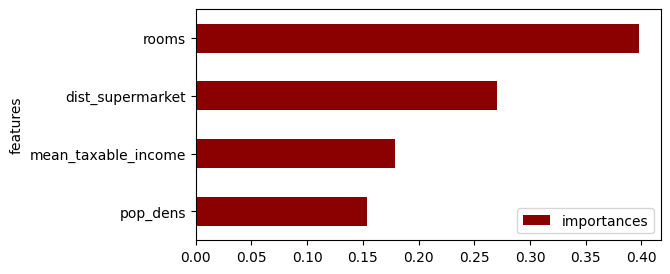

In [44]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = reg_rf.feature_importances_
std         = np.std([tree.feature_importances_ for tree in reg_rf.estimators_], axis=0)
indices     = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

plt.show()

### **Does the importance of features change (after removing `area`)?**

Yes, the importance of features changes after dropping the variable `area`. In the original model,  `area` is by far the most important feature, while `rooms` has the lowest importance; however, once `area` is removed, rooms becomes the most important feature. This happens because `area` and `rooms` could be partially correlated and capture similar information about property size (more space, more rooms generally), so when `area` is present it absorbs most of the explanatory power, and when it is removed the model shifts importance to the next most informative variable, in this case `rooms`.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [45]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-12-12 21:34:40
Python Version: 3.11.14
-----------------------------------
